# Urban Traffic Volume Prediction Using Machine Learning
## Graduation Thesis — Comprehensive ML Framework
---
**Dataset:** Metro Interstate Traffic Volume  
**Models Evaluated:** Linear Regression · Random Forest · XGBoost · LightGBM · SVR  
**Evaluation Criteria:** Accuracy (RMSE, MAE, R²) · Stability (Cross-Validation) · Computational Efficiency (Training Time)

## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import math
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Boosting Models
from xgboost import XGBRegressor
import lightgbm as lgb

# Visualization style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
PALETTE = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading & Initial Exploration

In [2]:
data = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
data.columns = data.columns.str.lower()

print('=== DATASET OVERVIEW ===')
print(f'Shape: {data.shape}')
print(f'\nColumn types:\n{data.dtypes}')
print(f'\nMissing values (%):\n{(data.isnull().sum()/len(data)*100).round(2)}')

=== DATASET OVERVIEW ===
Shape: (48204, 9)

Column types:
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

Missing values (%):
holiday                99.87
temp                    0.00
rain_1h                 0.00
snow_1h                 0.00
clouds_all              0.00
weather_main            0.00
weather_description     0.00
date_time               0.00
traffic_volume          0.00
dtype: float64


In [3]:
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
print('=== TARGET VARIABLE STATISTICS ===')
print(data['traffic_volume'].describe())

=== TARGET VARIABLE STATISTICS ===
count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


## 3. Exploratory Data Analysis (EDA)

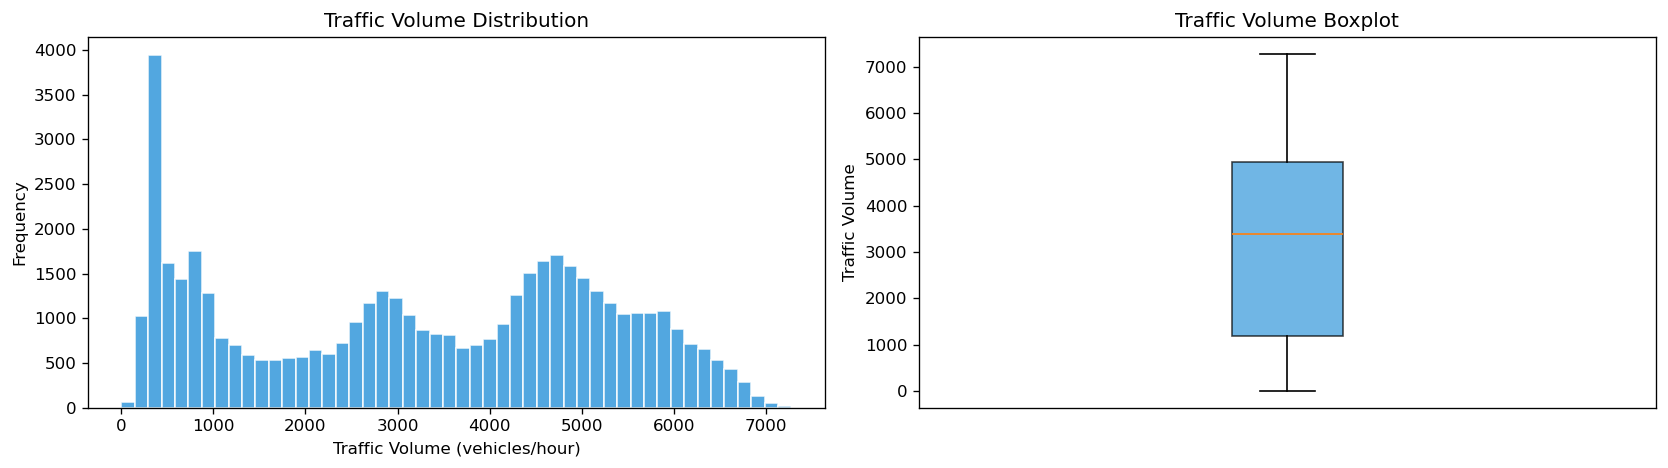

In [5]:
# ── Traffic Volume Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['traffic_volume'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Traffic Volume Distribution')
axes[0].set_xlabel('Traffic Volume (vehicles/hour)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(data['traffic_volume'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Traffic Volume Boxplot')
axes[1].set_ylabel('Traffic Volume')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

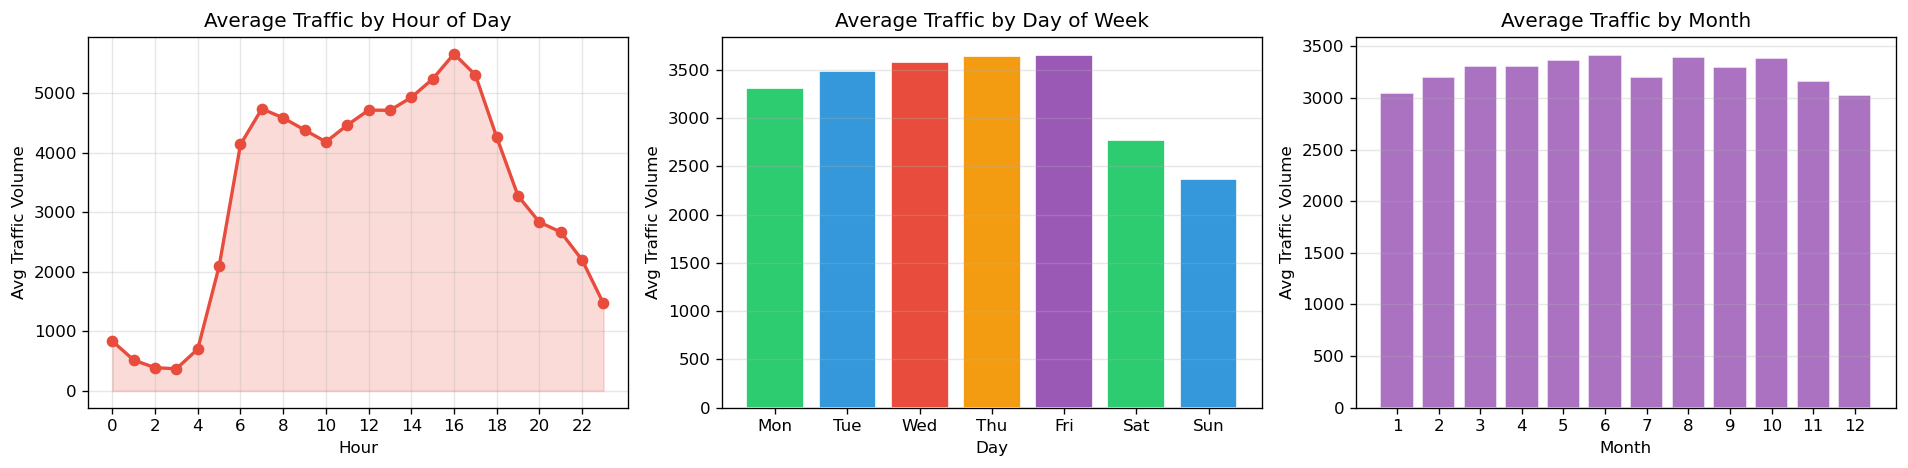

In [6]:
# ── Temporal Patterns ──
temp_data = data.copy()
temp_data['date_time'] = pd.to_datetime(temp_data['date_time'])
temp_data['hour'] = temp_data['date_time'].dt.hour
temp_data['day_of_week'] = temp_data['date_time'].dt.dayofweek
temp_data['month'] = temp_data['date_time'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

hourly = temp_data.groupby('hour')['traffic_volume'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='#e74c3c', linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='#e74c3c')
axes[0].set_title('Average Traffic by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Traffic Volume')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.3)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = temp_data.groupby('day_of_week')['traffic_volume'].mean()
axes[1].bar(days, daily.values, color=PALETTE[:7] if len(PALETTE)>=7 else PALETTE, edgecolor='white')
axes[1].set_title('Average Traffic by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Traffic Volume')
axes[1].grid(axis='y', alpha=0.3)

monthly = temp_data.groupby('month')['traffic_volume'].mean()
axes[2].bar(monthly.index, monthly.values, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].set_title('Average Traffic by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg Traffic Volume')
axes[2].set_xticks(range(1, 13))
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

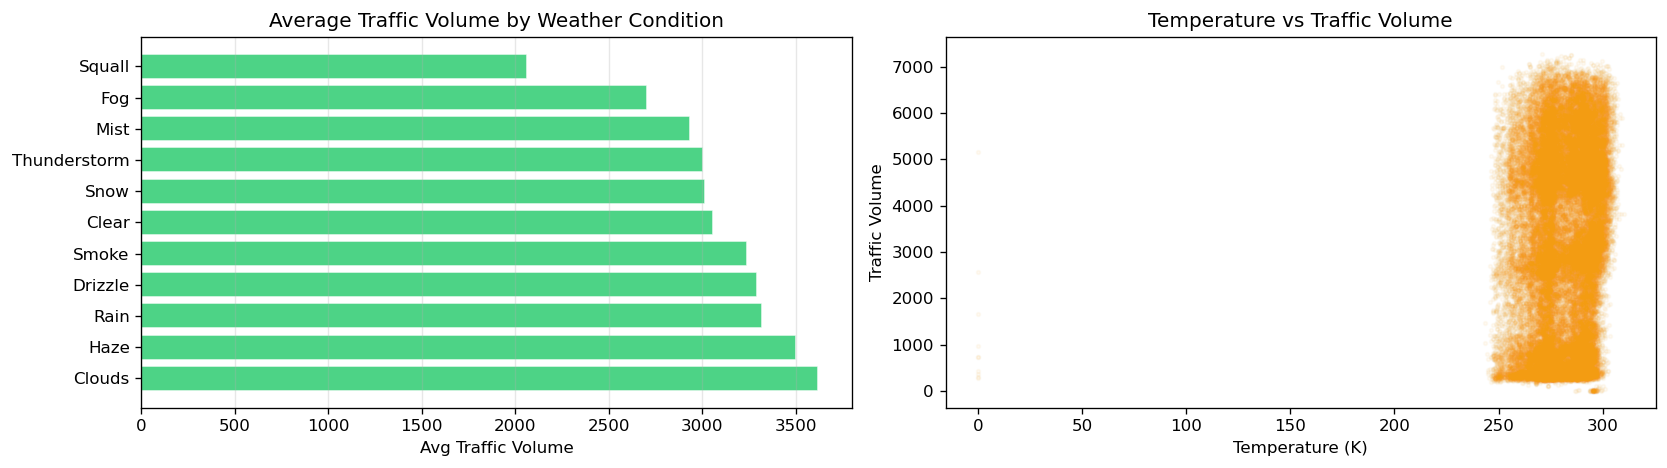

In [7]:
# ── Weather & Traffic ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weather_avg = data.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)
axes[0].barh(weather_avg.index, weather_avg.values, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_title('Average Traffic Volume by Weather Condition')
axes[0].set_xlabel('Avg Traffic Volume')
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(data['temp'], data['traffic_volume'], alpha=0.05, color='#f39c12', s=5)
axes[1].set_title('Temperature vs Traffic Volume')
axes[1].set_xlabel('Temperature (K)')
axes[1].set_ylabel('Traffic Volume')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

In [8]:
def preprocessing(data):
    df = data.copy()

    # ── DateTime Features ──────────────────────────
    df['date_time'] = pd.to_datetime(df['date_time'])
    df['hour']        = df['date_time'].dt.hour
    df['day_of_week'] = df['date_time'].dt.dayofweek
    df['month']       = df['date_time'].dt.month
    df['year']        = df['date_time'].dt.year
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

    # Rush hour: 7-9 AM and 4-7 PM on weekdays
    df['is_rush_hour'] = (
        (df['is_weekend'] == 0) &
        (df['hour'].isin([7, 8, 9, 16, 17, 18, 19]))
    ).astype(int)

    # Cyclical encoding for hour and month (preserves periodicity)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # ── Holiday & Rain ─────────────────────────────
    df['holiday'] = df['holiday'].notnull().astype(int)
    df['rain_1h'] = (df['rain_1h'] > 0).astype(int)

    # ── Temperature: convert Kelvin to Celsius, remove outliers ──
    df['temp_celsius'] = df['temp'] - 273.15
    df = df[(df['temp'] > 100) & (df['temp'] < 320)]

    # ── Drop irrelevant or leaky columns ───────────
    drop_cols = ['date_time', 'snow_1h', 'weather_description', 'temp']
    df = df.drop(columns=drop_cols)

    return df

df = preprocessing(data)
print(f'Preprocessed shape: {df.shape}')
print(f'Features: {list(df.columns)}')

Preprocessed shape: (48194, 16)
Features: ['holiday', 'rain_1h', 'clouds_all', 'weather_main', 'traffic_volume', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_celsius']


In [9]:
# ── One-Hot Encoding for categorical 'weather_main' ──
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True, dtype=int)

print(f'Final dataset shape after encoding: {df.shape}')
df.head(3)

Final dataset shape after encoding: (48194, 25)


,holiday,rain_1h,clouds_all,traffic_volume,hour,day_of_week,month,year,is_weekend,is_rush_hour,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,0,0,40,5545,9,1,10,2012,0,1,...,1,0,0,0,0,0,0,0,0,0
1,0,0,75,4516,10,1,10,2012,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,90,4767,11,1,10,2012,0,0,...,1,0,0,0,0,0,0,0,0,0


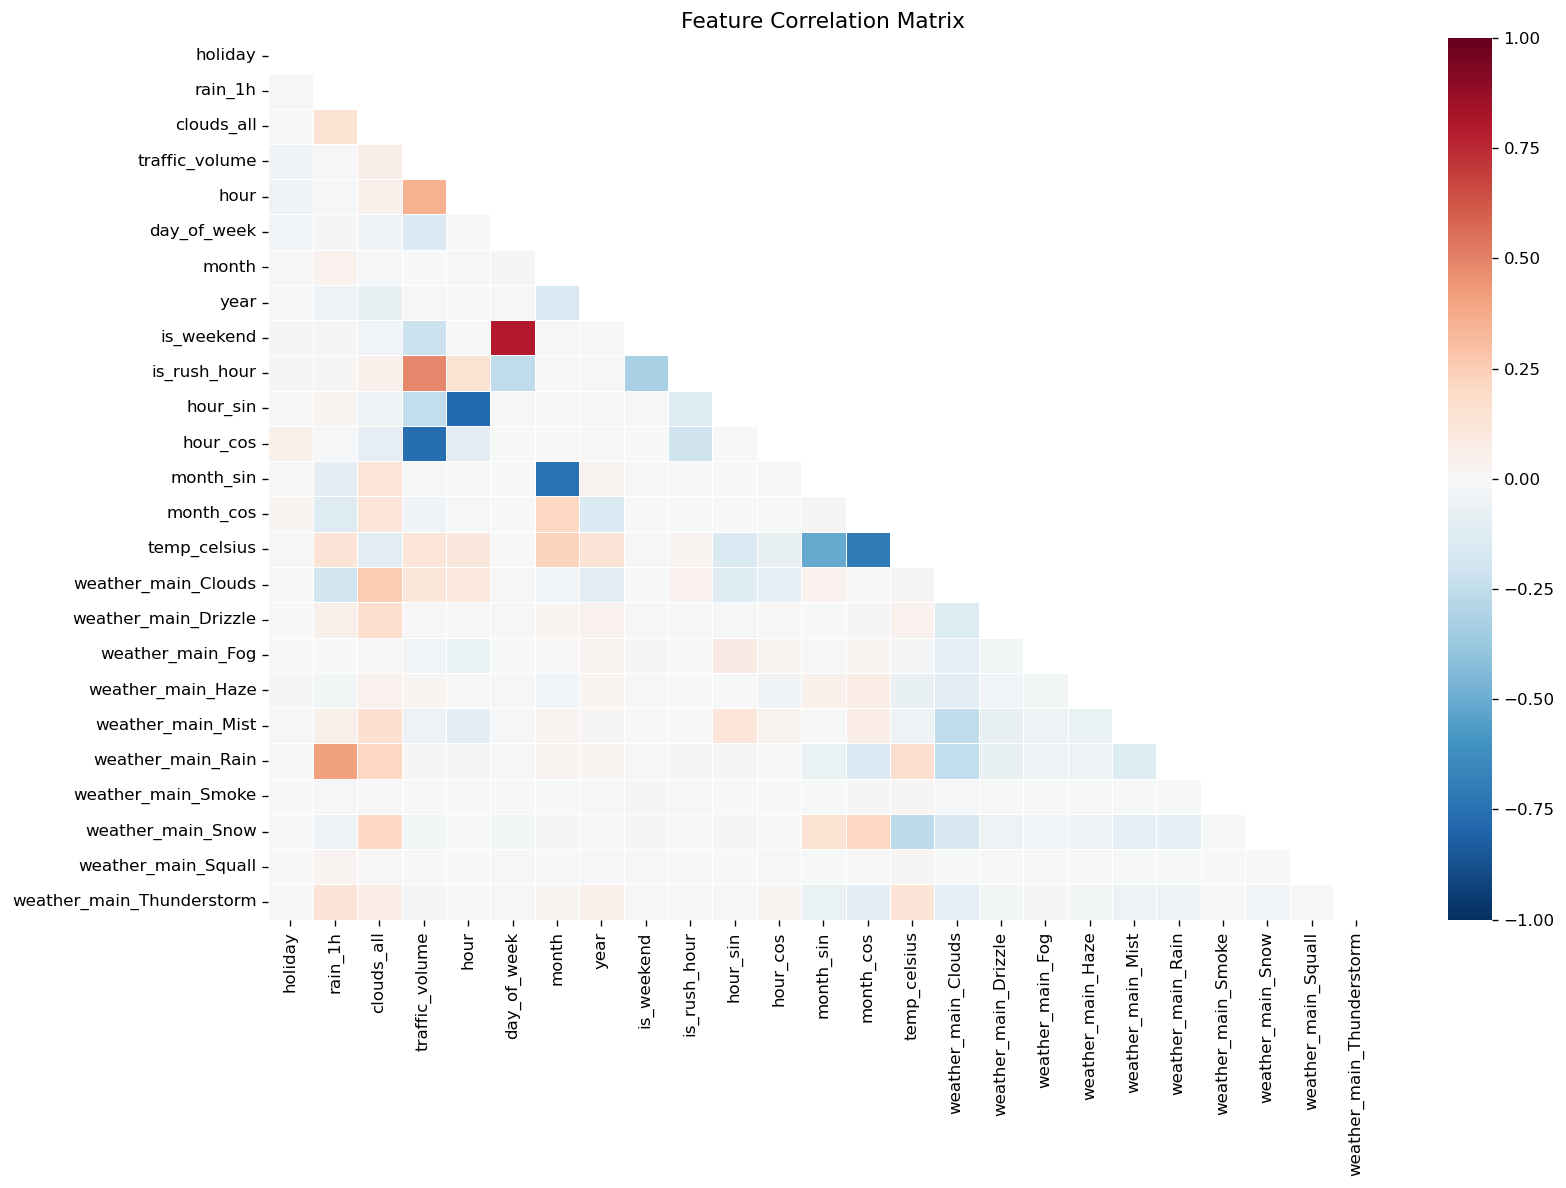


Top 10 correlations with traffic_volume:
hour_cos              -0.764
is_rush_hour           0.492
hour                   0.352
hour_sin              -0.244
is_weekend            -0.218
day_of_week           -0.149
temp_celsius           0.132
weather_main_Clouds    0.122
clouds_all             0.067
weather_main_Mist     -0.062
Name: traffic_volume, dtype: float64


In [10]:
# ── Correlation Heatmap ──
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix['traffic_volume'].drop('traffic_volume').sort_values(key=abs, ascending=False)
print('\nTop 10 correlations with traffic_volume:')
print(target_corr.head(10).round(3))

## 5. Train/Test Split

In [11]:
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape}')
print(f'Test set:      {X_test.shape}')

Training set:  (38555, 24)
Test set:      (9639, 24)


## 6. Model Training & Evaluation

We train **5 machine learning models** and evaluate them on three dimensions:
1. **Accuracy** — RMSE, MAE, R²
2. **Stability** — 5-Fold Cross-Validation RMSE
3. **Computational Efficiency** — Training time (seconds)

In [12]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, cv_folds=5):
    """Train, predict, and evaluate a model. Returns a result dict."""
    # Training time
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy metrics
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Cross-validation (neg_root_mean_squared_error)
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse_mean = -cv_scores.mean()
    cv_rmse_std  = cv_scores.std()

    print(f'\n[{name}]')
    print(f'  RMSE:           {rmse:,.1f}')
    print(f'  MAE:            {mae:,.1f}')
    print(f'  R²:             {r2:.4f}')
    print(f'  CV RMSE:        {cv_rmse_mean:,.1f} ± {cv_rmse_std:,.1f}')
    print(f'  Training time:  {train_time:.2f}s')

    return {
        'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'CV_RMSE_mean': cv_rmse_mean, 'CV_RMSE_std': cv_rmse_std,
        'Train_Time_s': train_time, 'y_pred': y_pred
    }

### 6.1 Linear Regression (Baseline)

In [13]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
res_lr = evaluate_model('Linear Regression', lr_pipe, X_train, X_test, y_train, y_test)


[Linear Regression]
  RMSE:           943.5
  MAE:            700.5
  R²:             0.7755
  CV RMSE:        941.4 ± 4.8
  Training time:  0.09s


### 6.2 Random Forest

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)
res_rf = evaluate_model('Random Forest', rf_model, X_train, X_test, y_train, y_test)


[Random Forest]
  RMSE:           417.2
  MAE:            232.1
  R²:             0.9561
  CV RMSE:        433.5 ± 8.8
  Training time:  4.11s


### 6.3 XGBoost

In [15]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
res_xgb = evaluate_model('XGBoost', xgb_model, X_train, X_test, y_train, y_test)


[XGBoost]
  RMSE:           374.6
  MAE:            211.1
  R²:             0.9646
  CV RMSE:        390.3 ± 9.3
  Training time:  2.00s


### 6.4 LightGBM

In [16]:
lgbm_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)
res_lgbm = evaluate_model('LightGBM', lgbm_model, X_train, X_test, y_train, y_test)


[LightGBM]
  RMSE:           396.3
  MAE:            223.1
  R²:             0.9604
  CV RMSE:        405.6 ± 8.8
  Training time:  0.90s


### 6.5 Support Vector Regression (SVR)

In [17]:
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVR(kernel='rbf', C=100, epsilon=50, gamma='scale'))
])
# SVR is slow on large datasets — use a subset for CV to keep runtime reasonable
svr_sample = min(8000, len(X_train))
idx = np.random.RandomState(42).choice(len(X_train), svr_sample, replace=False)

t0 = time.time()
svr_pipe.fit(X_train.iloc[idx], y_train.iloc[idx])
svr_time = time.time() - t0

y_pred_svr = svr_pipe.predict(X_test)
rmse_svr = math.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
r2_svr   = r2_score(y_test, y_pred_svr)

# Quick 3-fold CV on sample for SVR
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_svr = cross_val_score(svr_pipe, X_train.iloc[idx], y_train.iloc[idx],
                          cv=kf, scoring='neg_root_mean_squared_error')

res_svr = {
    'Model': 'SVR', 'RMSE': rmse_svr, 'MAE': mae_svr, 'R2': r2_svr,
    'CV_RMSE_mean': -cv_svr.mean(), 'CV_RMSE_std': cv_svr.std(),
    'Train_Time_s': svr_time, 'y_pred': y_pred_svr
}

print('[SVR]')
print(f'  RMSE:           {rmse_svr:,.1f}')
print(f'  MAE:            {mae_svr:,.1f}')
print(f'  R²:             {r2_svr:.4f}')
print(f'  CV RMSE:        {-cv_svr.mean():,.1f} ± {cv_svr.std():,.1f}')
print(f'  Training time:  {svr_time:.2f}s  (trained on {svr_sample} samples)')

[SVR]
  RMSE:           924.4
  MAE:            601.8
  R²:             0.7845
  CV RMSE:        947.5 ± 14.0
  Training time:  2.63s  (trained on 8000 samples)


## 7. Comparative Analysis

In [18]:
results = [res_lr, res_rf, res_xgb, res_lgbm, res_svr]
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'} for r in results])
results_df = results_df.set_index('Model')

# Rank by RMSE
results_df['Rank'] = results_df['RMSE'].rank().astype(int)
print('=== MODEL COMPARISON TABLE ===')
print(results_df[['RMSE','MAE','R2','CV_RMSE_mean','CV_RMSE_std','Train_Time_s','Rank']]
      .round(2).sort_values('Rank').to_string())

=== MODEL COMPARISON TABLE ===
                     RMSE     MAE    R2  CV_RMSE_mean  CV_RMSE_std  Train_Time_s  Rank
Model                                                                                 
XGBoost            374.58  211.14  0.96        390.26         9.34          2.00     1
LightGBM           396.26  223.10  0.96        405.63         8.84          0.90     2
Random Forest      417.24  232.08  0.96        433.52         8.77          4.11     3
SVR                924.39  601.83  0.78        947.49        13.98          2.63     4
Linear Regression  943.47  700.55  0.78        941.39         4.81          0.09     5


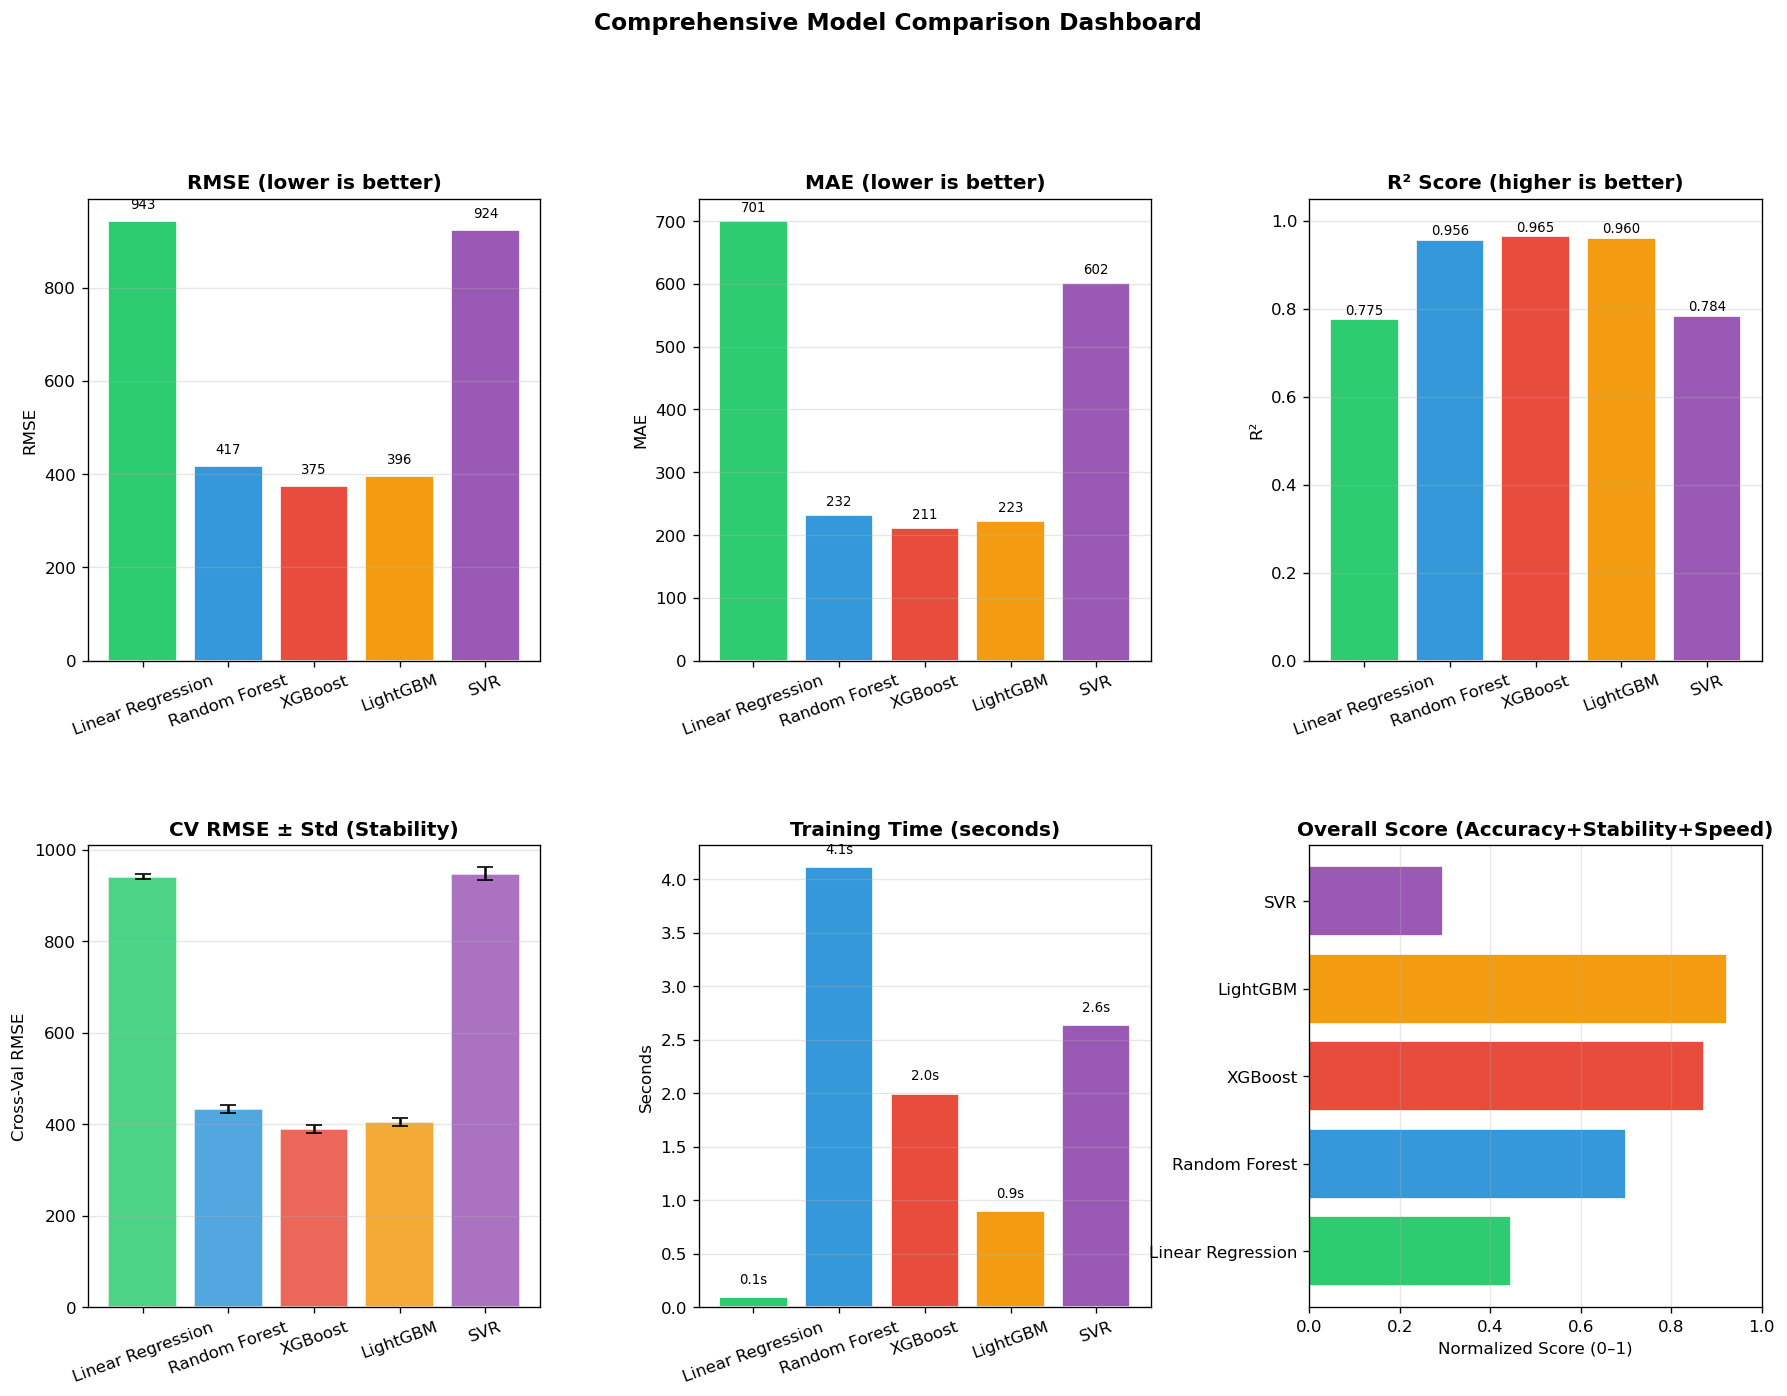

In [19]:
# ── Comprehensive Comparison Dashboard ──
model_names = results_df.index.tolist()
colors      = PALETTE[:len(model_names)]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1) RMSE
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(model_names, results_df['RMSE'], color=colors, edgecolor='white')
ax1.set_title('RMSE (lower is better)', fontweight='bold')
ax1.set_ylabel('RMSE')
ax1.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, results_df['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# 2) MAE
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(model_names, results_df['MAE'], color=colors, edgecolor='white')
ax2.set_title('MAE (lower is better)', fontweight='bold')
ax2.set_ylabel('MAE')
ax2.tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, results_df['MAE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# 3) R²
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(model_names, results_df['R2'], color=colors, edgecolor='white')
ax3.set_title('R² Score (higher is better)', fontweight='bold')
ax3.set_ylabel('R²')
ax3.set_ylim(0, 1.05)
ax3.tick_params(axis='x', rotation=20)
for bar, val in zip(bars3, results_df['R2']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# 4) CV RMSE with error bars (Stability)
ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(model_names, results_df['CV_RMSE_mean'], color=colors, edgecolor='white',
        yerr=results_df['CV_RMSE_std'], capsize=5, alpha=0.85)
ax4.set_title('CV RMSE ± Std (Stability)', fontweight='bold')
ax4.set_ylabel('Cross-Val RMSE')
ax4.tick_params(axis='x', rotation=20)
ax4.grid(axis='y', alpha=0.3)

# 5) Training time
ax5 = fig.add_subplot(gs[1, 1])
bars5 = ax5.bar(model_names, results_df['Train_Time_s'], color=colors, edgecolor='white')
ax5.set_title('Training Time (seconds)', fontweight='bold')
ax5.set_ylabel('Seconds')
ax5.tick_params(axis='x', rotation=20)
for bar, val in zip(bars5, results_df['Train_Time_s']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=8)
ax5.grid(axis='y', alpha=0.3)

# 6) Radar / Spider: normalized scores
ax6 = fig.add_subplot(gs[1, 2])
# Normalized: lower RMSE → higher score
norm_rmse  = 1 - (results_df['RMSE']  - results_df['RMSE'].min()) / (results_df['RMSE'].max()  - results_df['RMSE'].min() + 1e-9)
norm_r2    = results_df['R2']
norm_speed = 1 - (results_df['Train_Time_s'] - results_df['Train_Time_s'].min()) / (results_df['Train_Time_s'].max() - results_df['Train_Time_s'].min() + 1e-9)
norm_stab  = 1 - (results_df['CV_RMSE_mean'] - results_df['CV_RMSE_mean'].min()) / (results_df['CV_RMSE_mean'].max() - results_df['CV_RMSE_mean'].min() + 1e-9)

combined = (norm_rmse + norm_r2 + norm_speed + norm_stab) / 4
ax6.barh(model_names, combined, color=colors, edgecolor='white')
ax6.set_title('Overall Score (Accuracy+Stability+Speed)', fontweight='bold')
ax6.set_xlabel('Normalized Score (0–1)')
ax6.set_xlim(0, 1)
ax6.grid(axis='x', alpha=0.3)

plt.suptitle('Comprehensive Model Comparison Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.show()

## 8. Prediction vs Actual Analysis

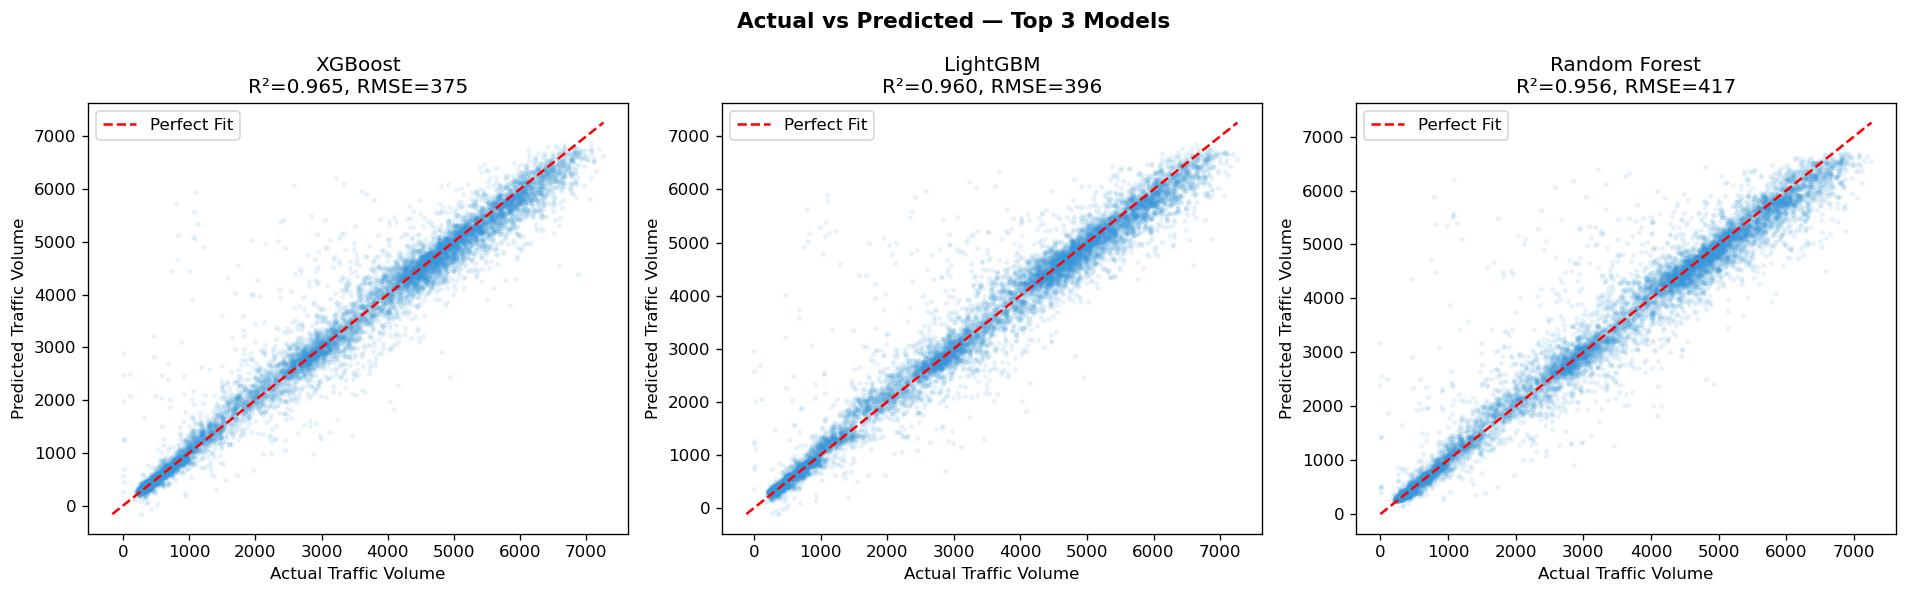

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

top_3_results = sorted(results, key=lambda r: r['RMSE'])[:3]
for ax, res in zip(axes, top_3_results):
    y_pred = res['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.08, s=5, color='#3498db')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
    ax.set_title(f"{res['Model']}\nR²={res['R2']:.3f}, RMSE={res['RMSE']:,.0f}")
    ax.set_xlabel('Actual Traffic Volume')
    ax.set_ylabel('Predicted Traffic Volume')
    ax.legend()

plt.suptitle('Actual vs Predicted — Top 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

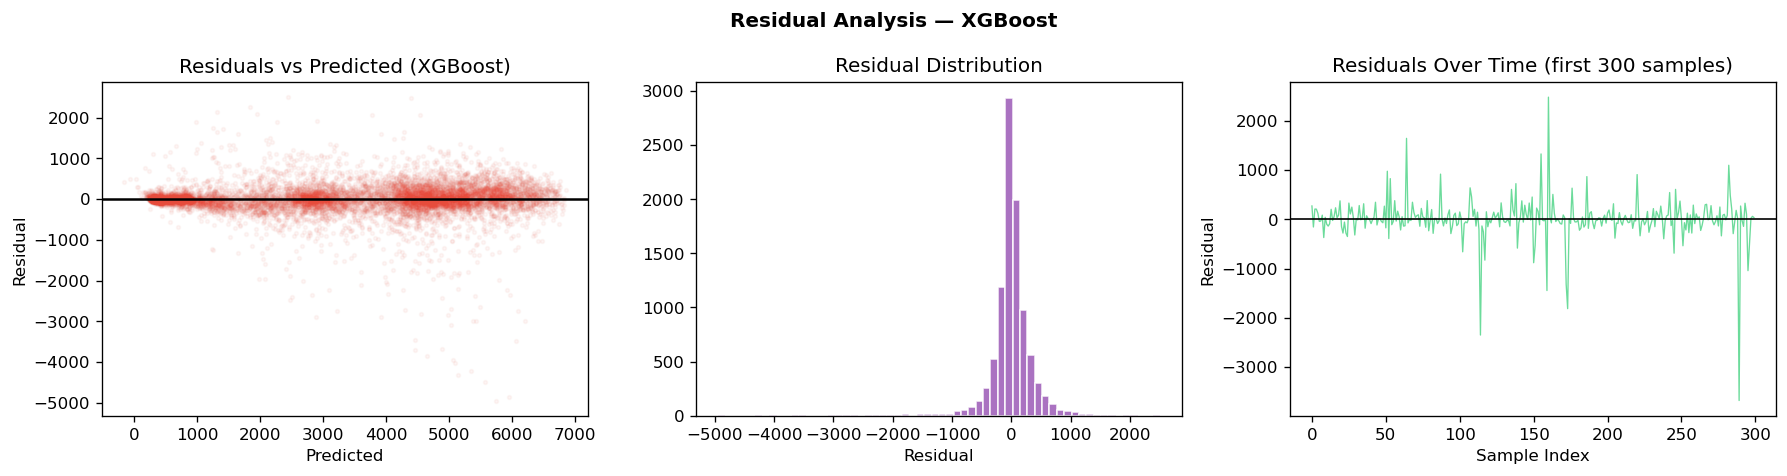

In [21]:
# ── Residual Analysis for Best Model ──
best = min(results, key=lambda r: r['RMSE'])
residuals = y_test.values - best['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(best['y_pred'], residuals, alpha=0.05, s=5, color='#e74c3c')
axes[0].axhline(0, color='black', lw=1.5)
axes[0].set_title(f"Residuals vs Predicted ({best['Model']})")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

# Time-ordered residuals (first 300 test points)
axes[2].plot(residuals[:300], color='#2ecc71', alpha=0.7, linewidth=0.8)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_title('Residuals Over Time (first 300 samples)')
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Residual')

plt.suptitle(f'Residual Analysis — {best["Model"]}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance

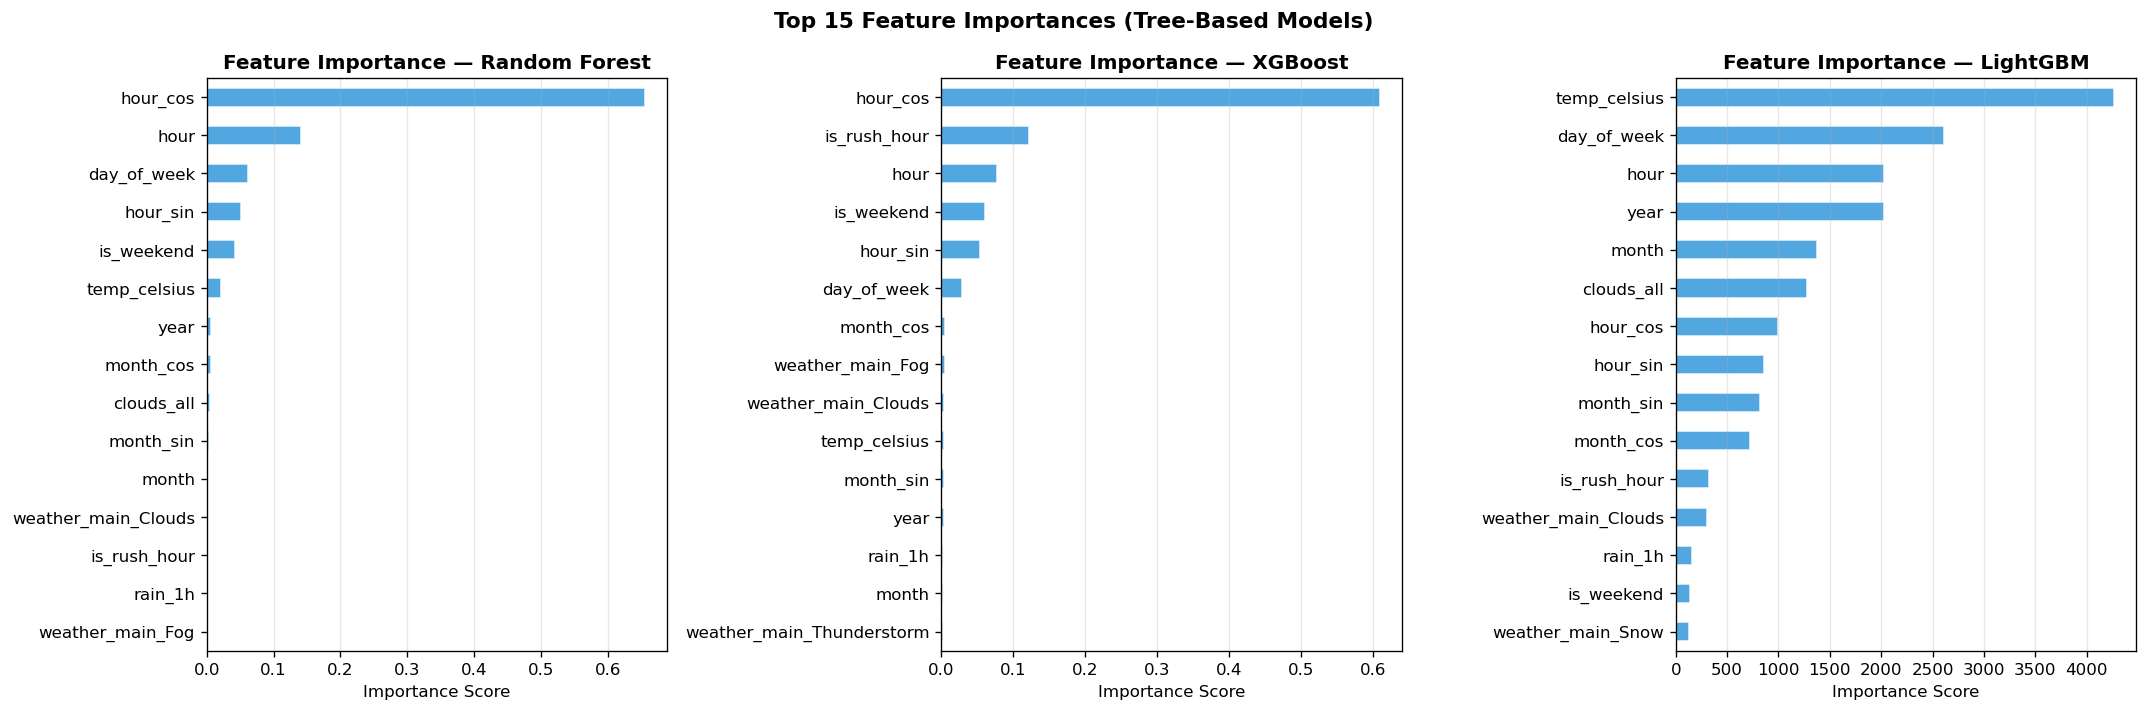

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tree_models = [
    ('Random Forest', rf_model),
    ('XGBoost',       xgb_model),
    ('LightGBM',      lgbm_model),
]

for ax, (name, model) in zip(axes, tree_models):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top15 = importances.sort_values(ascending=True).tail(15)
    top15.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white', alpha=0.85)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 15 Feature Importances (Tree-Based Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Results Summary & Conclusions

In [1]:
summary = results_df[['RMSE','MAE','R2','CV_RMSE_mean','CV_RMSE_std','Train_Time_s']].copy()
summary.columns = ['RMSE', 'MAE', 'R²', 'CV RMSE (mean)', 'CV RMSE (std)', 'Train Time (s)']
summary = summary.sort_values('RMSE')


print('FINAL MODEL COMPARISON — SORTED BY RMSE (Best to Worst)')
print('='*75)
print(summary.round(3).to_string())
print('='*75)

best_model = summary.index[0]
print(f'\n BEST MODEL: {best_model}')
print(f'   RMSE = {summary.loc[best_model, "RMSE"]:,.1f}')
print(f'   R²   = {summary.loc[best_model, "R²"]:.4f}')
print(f'   MAE  = {summary.loc[best_model, "MAE"]:,.1f}')

NameError: name 'results_df' is not defined